# generate results for Fig. 4

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.rc('font',family='Arial')
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.size'] = 10
import matplotlib.colors as mcolors

import seaborn as sns

import palettable.colorbrewer.sequential as palet

import time
start_time = time.time()
print(time.ctime())

from dynamic_stock_model import DynamicStockModel

file_path = 'C:/Users/xmuxi/Desktop/2-UCAS/4-Co-Ni-Cu/Data/'

Sun Aug  2 16:05:00 2026


- population (million persons)

In [3]:
df_pop = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='Population', index_col=[0], header=2)
df_pop.head(2)

,China,Japan,EU,USA,RoW,World
Region,,,,,,
1900,400.265000,44.103,278.2490,76.391,527.86193,1326.869930
1901,402.520077,44.662,280.5497,77.888,532.84672,1338.466497


In [4]:
Materials = ['Cobalt','Nickel','Copper']

IEA_Scenarios = ['STEPS','APS','NZES']

Regions = ['China','Japan','EU','USA','RoW']
Region_Colors = ['#D62728','#2CA02C','#FF7F0E','#1F77B4','#7F7F7F']

Primary_Scenarios = ['Baseline (SP)','Copper-driven','Laterite Nickel-driven','All carriers-driven']
Secondary_Scenarios = ['Constant','High']
Process_Scenarios = ['Constant','Efficient']
Lifetime_Scenarios = ['Constant','Longer']

Segment_Scenarios = ['Baseline']
#Segment_Scenarios = ['Baseline','Smaller','Larger']

Battery_Sizes = ['Larger']
#Battery_Sizes = ['Constant','Larger']

Battery_Scenarios = ['Baseline','NCM', 'NMA', 'LFP/LMFP', 'Na-ion']

Mining_Scenarios = ['Baseline (SP)','Copper-driven','Laterite Nickel-driven','All Carrier-driven']
Mining_Sources = ['Cobalt_from_Cobalt','Cobalt_from_Copper','Cobalt_from_Sulfide_Nickel','Cobalt_from_Laterite_Nickel']

Agg_Sectors = ['Building & Infrastructure','Transportation','Industrial Equipment','Metal Goods & Others','B-CEs','B-EVs','B-ESS',]

## Demand: Bottom-up (Emerging use)

In [5]:
Year_Min = 2025

def full_fill(df):
    df_temp = pd.DataFrame(index=np.arange(Year_Min,df.index.min()), columns=df.columns)
    df_temp.fillna(value=0, inplace=True)
    df_output  = pd.concat([df_temp, df])
    
    return df_output

- ESS (kt)

In [6]:
df_ESS_stock = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_stock', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_stock = df_ESS_stock.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime']).sum()
df_ESS_stock = df_ESS_stock.T
df_ESS_stock = full_fill(df_ESS_stock)

df_ESS_inflow = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_inflow', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_inflow = df_ESS_inflow.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime']).sum()
df_ESS_inflow = df_ESS_inflow.T
df_ESS_inflow = full_fill(df_ESS_inflow)

df_ESS_outflow = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_outflow', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_outflow = df_ESS_outflow.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime']).sum()
df_ESS_outflow = df_ESS_outflow.T
df_ESS_outflow = full_fill(df_ESS_outflow)

df_ESS_inflow.head(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_12308\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output  = pd.concat([df_temp, df])
C:\Users\xmuxi\AppData\Local\Temp\ipykernel_12308\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output  = pd.concat([df_temp, df])
C:\Users\xmuxi\AppData\Local\Temp\ipykernel_12308\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will n

Material            Cobalt                                                    \
ESS Scenario           APS                                                     
Battery Scenario  Baseline            LFP/LMFP                 NMA             
Lifetime          Constant    Longer  Constant    Longer  Constant    Longer   
2010              0.090164  0.090164  0.090164  0.090164  0.090164  0.090164   
2011              0.037165  0.037165  0.037165  0.037165  0.037165  0.037165   

Material                                                  ...    Nickel  \
ESS Scenario                                              ...     STEPS   
Battery Scenario       NMC              Na-ion            ...  LFP/LMFP   
Lifetime          Constant    Longer  Constant    Longer  ...  Constant   
2010              0.090164  0.090164  0.090164  0.090164  ...  0.266726   
2011              0.037165  0.037165  0.037165  0.037165  ...  0.109941   

Material                                                                      \
ESS Scenario                                                                   
Battery Scenario                 NMA                 NMC              Na-ion   
Lifetime            Longer  Constant    Longer  Constant    Longer  Constant   
2010              0.266726  0.266726  0.266726  0.266726  0.266726  0.266726   
2011              0.109941  0.109941  0.109941  0.109941  0.109941  0.109941   

Material                                        
ESS Scenario                                    
Battery Scenario           Optimized            
Lifetime            Longer  Constant    Longer  
2010              0.266726  0.266726  0.266726  
2011              0.109941  0.109941  0.109941  

[2 rows x 108 columns]

- vehicle: battery material (kt)

In [7]:
df_EV_stock = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_stock', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_stock = df_EV_stock.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime']).sum()
df_EV_stock = df_EV_stock.T
df_EV_stock = full_fill(df_EV_stock)

df_EV_inflow = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_inflow', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_inflow = df_EV_inflow.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime']).sum()
df_EV_inflow = df_EV_inflow.T
df_EV_inflow = full_fill(df_EV_inflow)

df_EV_outflow = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_outflow', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_outflow = df_EV_outflow.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime']).sum()
df_EV_outflow = df_EV_outflow.T
df_EV_outflow = full_fill(df_EV_outflow)

df_EV_outflow.head(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_12308\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output  = pd.concat([df_temp, df])
C:\Users\xmuxi\AppData\Local\Temp\ipykernel_12308\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output  = pd.concat([df_temp, df])
C:\Users\xmuxi\AppData\Local\Temp\ipykernel_12308\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will n

Material               Cobalt                                          \
Powertrain Scenario       APS                                           
Segment Scenario     Baseline                                           
Battery Size           Larger                                           
Battery Scenario     Baseline            LFP/LMFP                 NMA   
Lifetime             Constant    Longer  Constant    Longer  Constant   
2005                 0.000006  0.000006  0.000006  0.000006  0.000006   
2006                 0.000020  0.000020  0.000020  0.000020  0.000020   

Material                                                               ...  \
Powertrain Scenario                                                    ...   
Segment Scenario                                                       ...   
Battery Size                                                           ...   
Battery Scenario                    NMC              Na-ion            ...   
Lifetime               Longer  Constant    Longer  Constant    Longer  ...   
2005                 0.000006  0.000006  0.000006  0.000006  0.000006  ...   
2006                 0.000020  0.000020  0.000020  0.000020  0.000020  ...   

Material               Nickel                                          \
Powertrain Scenario     STEPS                                           
Segment Scenario     Baseline                                           
Battery Size           Larger                                           
Battery Scenario     LFP/LMFP                 NMA                 NMC   
Lifetime             Constant    Longer  Constant    Longer  Constant   
2005                 0.000009  0.000009  0.000009  0.000009  0.000009   
2006                 0.000029  0.000029  0.000029  0.000029  0.000029   

Material                                                               
Powertrain Scenario                                                    
Segment Scenario                                                       
Battery Size                                                           
Battery Scenario                 Na-ion           Optimized            
Lifetime               Longer  Constant    Longer  Constant    Longer  
2005                 0.000009  0.000009  0.000009  0.000009  0.000009  
2006                 0.000029  0.000029  0.000029  0.000029  0.000029  

[2 rows x 108 columns]

## Copper cycle

In [8]:
Cu_Sectors = ['Building & Construction','Infrastructure','Transport','Industrial Equipment','Other Products']

Cu_New_Sectors = ['Building & Construction','Infrastructure','Transport (Exclude B-EVs)','Industrial Equipment','Other Products (Exclude B-ESS)', 'B-ESS', 'B-EVs']
Cu_Old_Sectors = ['Building & Construction','Infrastructure','Transport (Exclude B-EVs)','Industrial Equipment','Other Products (Exclude B-ESS)']
Cu_Agg_Sectors = ['Building & Infrastructure','Transportation','Industrial Equipment','B-CEs','B-EVs','B-ESS',]

- Copper per capita stock (kg/person)

In [9]:
df_Cu_per_capita = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='per capita traditional use', index_col=[0], header=[5])
df_Cu_per_capita = df_Cu_per_capita.loc[:2050:]
df_Cu_per_capita.tail(2)

,Building & Construction,Infrastructure,Transport (Exclude B-EVs),Industrial Equipment,Other Products (Exclude B-ESS),Total
Sector,,,,,,
2049,51.025553,18.937606,7.981351,8.650224,7.054912,93.649647
2050,51.235015,19.378207,8.327024,8.856932,7.322852,95.120030


- lifetime

In [10]:
df_Cu_lifetime = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='lifetime', index_col=[0,1], header=2)
df_Cu_lifetime = df_Cu_lifetime.T
df_Cu_lifetime.head(2)

Lifetime Scenario                Constant                                 \
Sector            Building & Construction Infrastructure B-EVs Transport   
1900                                 40.0           34.0   NaN      17.0   
1901                                 40.0           34.0   NaN      17.0   

Lifetime Scenario                                                       \
Sector            Transport (Exclude B-EVs) Industrial Equipment B-ESS   
1900                                   17.0                 17.0   NaN   
1901                                   17.0                 17.0   NaN   

Lifetime Scenario                                                \
Sector            Other Products Other Products (Exclude B-ESS)   
1900                        13.0                           13.0   
1901                        13.0                           13.0   

Lifetime Scenario                  Longer                                 \
Sector            Building & Construction Infrastructure B-EVs Transport   
1900                                 40.0           34.0   NaN      17.0   
1901                                 40.0           34.0   NaN      17.0   

Lifetime Scenario                                                       \
Sector            Transport (Exclude B-EVs) Industrial Equipment B-ESS   
1900                                   17.0                 17.0   NaN   
1901                                   17.0                 17.0   NaN   

Lifetime Scenario                                                
Sector            Other Products Other Products (Exclude B-ESS)  
1900                        13.0                           13.0  
1901                        13.0                           13.0

- Copper Traditional use 
- stock, inflow, outflow
- million persons * kg/person = kt

In [11]:
def cal_traditional_stock_flow(df_pop, df_capita, df_lt, Old_Sectors):
    
    df_stock = pd.DataFrame(index=df_capita.index, 
                             columns=pd.MultiIndex.from_product([Lifetime_Scenarios,Old_Sectors],names=['Lifetime','Sector']))
    df_inflow = df_stock.copy()
    df_outflow = df_inflow.copy()
    
    for lt in Lifetime_Scenarios:
        for s in Old_Sectors:
            df_stock[(lt,s)] = df_pop['World'] * df_capita[s]
            ## stock-driven
            DSM = DynamicStockModel(t = list(df_stock.index), 
                                    s = list(df_stock[(lt,s)]), 
                                    lt = {'Type': 'Normal',
                                          'Mean': list(df_lt[(lt,s)]),    
                                          'StdDev': list(0.3 * df_lt[(lt,s)])})
            DSM.compute_stock_driven_model()
            DSM.compute_outflow_total()
            ## fill in
            df_inflow[(lt,s)] = DSM.i
            df_outflow[(lt,s)] = DSM.o
                
    ## 第二轮
    df_inflow_2 = df_inflow.mask(df_inflow<0, 0)
    df_stock_2 = pd.DataFrame(index=df_capita.index, 
                              columns=pd.MultiIndex.from_product([Lifetime_Scenarios,Old_Sectors],names=['Lifetime','Sector']))
    df_outflow_2 = df_stock_2.copy()
    
    for lt in Lifetime_Scenarios:
        for s in Old_Sectors:
            ## inflow-driven
            DSM = DynamicStockModel(t = list(df_inflow_2.index), 
                                    i = list(df_inflow_2[(lt,s)]), 
                                    lt = {'Type': 'Normal',
                                          'Mean': list(df_lt[(lt,s)]),    
                                          'StdDev': list(0.3 * df_lt[(lt,s)])})
            DSM.compute_s_c_inflow_driven()
            DSM.compute_stock_total()
            DSM.compute_o_c_from_s_c()
            DSM.compute_outflow_total()
            ## fill in 
            df_stock_2[(lt,s)] = DSM.s
            df_outflow_2[(lt,s)] = DSM.o
                
    return df_stock_2, df_inflow_2, df_outflow_2


df_Cu_traditional_stock, df_Cu_traditional_inflow, df_Cu_traditional_outflow = cal_traditional_stock_flow(df_pop, df_Cu_per_capita, df_Cu_lifetime, Cu_Old_Sectors)
df_Cu_traditional_stock = df_Cu_traditional_stock.loc[Year_Min:,:]
df_Cu_traditional_inflow = df_Cu_traditional_inflow.loc[Year_Min:,:]
df_Cu_traditional_outflow = df_Cu_traditional_outflow.loc[Year_Min:,:]
df_Cu_traditional_inflow.head(2)

Lifetime                Constant                                           \
Sector   Building & Construction Infrastructure Transport (Exclude B-EVs)   
Sector                                                                      
2025                 9289.358031    3494.316231               2287.131327   
2026                 9171.777626    3542.086418               2344.233269   

Lifetime                                                      \
Sector   Industrial Equipment Other Products (Exclude B-ESS)   
Sector                                                         
2025              2877.911034                    2558.271193   
2026              2942.644061                    2629.279972   

Lifetime                  Longer                                           \
Sector   Building & Construction Infrastructure Transport (Exclude B-EVs)   
Sector                                                                      
2025                 9289.332077    3494.306335               2287.120192   
2026                 9171.704965    3542.054976               2344.178537   

Lifetime                                                      
Sector   Industrial Equipment Other Products (Exclude B-ESS)  
Sector                                                        
2025              2877.892932                    2558.248508  
2026              2942.564473                    2629.161311

- dissipation loss rate

In [12]:
df_Cu_dissipation_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='dissipation', index_col=[0], header=2)
df_Cu_dissipation_rate

,Dissipation rate
Sector,
Building & Construction,0.002
Infrastructure,0.006
Transport,0.004
Transport (Exclude B-EVs),0.004
B-EVs,0.004
Industrial Equipment,0.000
Other Products,0.020
Other Products (Exclude B-ESS),0.020
B-ESS,0.020


- loss rate

In [13]:
df_Cu_parameters = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='parameters', index_col=[0,1], header=2)
df_Cu_parameters = df_Cu_parameters.T
df_Cu_parameters = df_Cu_parameters.loc[Year_Min:,:]
df_Cu_parameters.head(2)

Scenario          Constant                                            \
Loss rate mining loss rate benefication loss rate smelting loss rate   
2025               0.06945                 0.1346             0.0129   
2026               0.06945                 0.1346             0.0129   

Scenario                                                   \
Loss rate refining loss rate primary processing loss rate   
2025                  0.0051                         0.06   
2026                  0.0051                         0.06   

Scenario                                                     \
Loss rate manufacturing loss rate new scrap collection rate   
2025                         0.17                      0.92   
2026                         0.17                      0.92   

Scenario                                                        Efficient  \
Loss rate old scrap collection rate recycling efficiency mining loss rate   
2025                           0.45                 0.92         0.065977   
2026                           0.45                 0.92         0.062679   

Scenario                                                                \
Loss rate benefication loss rate smelting loss rate refining loss rate   
2025                    0.127870           0.012255           0.004845   
2026                    0.121476           0.011642           0.004603   

Scenario                                                        \
Loss rate primary processing loss rate manufacturing loss rate   
2025                           0.05700                0.161500   
2026                           0.05415                0.153425   

Scenario                                                       \
Loss rate new scrap collection rate old scrap collection rate   
2025                       0.929200                  0.454500   
2026                       0.938492                  0.459045   

Scenario                        
Loss rate recycling efficiency  
2025                  0.929200  
2026                  0.938492

- scrap ratio

In [14]:
df_Cu_scrap_ratio = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='scrap ratio', index_col=[0], header=2)
df_Cu_scrap_ratio

,Value
Indicator,
Clean scrap ratio of new scrap,0.90
Clean scrap ratio of old scrap,0.33


## Nickel cycle

In [15]:
Ni_Sectors = ['Building & Infrastructure','Transportation','Industrial Machinery','Applications & Electronics','Metal Goods & Others']
Ni_New_Sectors = ['Building & Infrastructure','Transportation (Exclude B-EVs)','Industrial Machinery','Applications & Electronics (Exclude B-ESS)','Metal Goods & Others','B-ESS','B-EVs']
Ni_Old_Sectors = ['Building & Infrastructure','Transportation (Exclude B-EVs)','Industrial Machinery','Applications & Electronics (Exclude B-ESS)','Metal Goods & Others']
Ni_Agg_Sectors = ['Building & Infrastructure','Transportation','Industrial Equipment','Metal Goods & Others','B-CEs','B-EVs','B-ESS',]

- Nickel per capita (kg/person)

In [16]:
df_Ni_per_capita = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='per capita traditional use', index_col=[0], header=[5])
df_Ni_per_capita = df_Ni_per_capita.loc[:2050:]
df_Ni_per_capita.tail(2)

,Building & Infrastructure,Transportation (Exclude B-EVs),Industrial Machinery,Applications & Electronics (Exclude B-ESS),Metal Goods & Others,Total
Sector,,,,,,
2049,2.224502,2.250602,4.045783,1.158639,2.101553,11.781080
2050,2.260995,2.301909,4.094573,1.175339,2.173898,12.006714


- lifetime

In [17]:
df_Ni_lifetime = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='lifetime', index_col=[0,1], header=2)
df_Ni_lifetime = df_Ni_lifetime.T
df_Ni_lifetime.head(2)

Scenario                  Constant                 \
Sector   Building & Infrastructure Transportation   
1900                          30.0           25.0   
1901                          30.0           25.0   

Scenario                                                            \
Sector   Transportation (Exclude B-EVs) B-EVs Industrial Machinery   
1900                               25.0   NaN                 50.0   
1901                               25.0   NaN                 50.0   

Scenario                             \
Sector   Applications & Electronics   
1900                           14.0   
1901                           14.0   

Scenario                                                   \
Sector   Applications & Electronics (Exclude B-ESS) B-ESS   
1900                                           14.0   NaN   
1901                                           14.0   NaN   

Scenario                                         Longer                 \
Sector   Metal Goods & Others Building & Infrastructure Transportation   
1900                     15.0                      50.0           18.0   
1901                     15.0                      50.0           18.0   

Scenario                                                            \
Sector   Transportation (Exclude B-EVs) B-EVs Industrial Machinery   
1900                               18.0   NaN                 25.0   
1901                               18.0   NaN                 25.0   

Scenario                             \
Sector   Applications & Electronics   
1900                           15.0   
1901                           15.0   

Scenario                                                                        
Sector   Applications & Electronics (Exclude B-ESS) B-ESS Metal Goods & Others  
1900                                           15.0   NaN                 15.0  
1901                                           15.0   NaN                 15.0

- Nickel Traditional use 
- stock, inflow, outflow
- million persons * kg/person = kt

In [18]:
df_Ni_traditional_stock, df_Ni_traditional_inflow, df_Ni_traditional_outflow = cal_traditional_stock_flow(df_pop, df_Ni_per_capita, df_Ni_lifetime, Ni_Old_Sectors)
df_Ni_traditional_stock = df_Ni_traditional_stock.loc[Year_Min:,:]
df_Ni_traditional_inflow = df_Ni_traditional_inflow.loc[Year_Min:,:]
df_Ni_traditional_outflow = df_Ni_traditional_outflow.loc[Year_Min:,:]
df_Ni_traditional_inflow.tail(2)

Lifetime                  Constant                                 \
Sector   Building & Infrastructure Transportation (Exclude B-EVs)   
Sector                                                              
2049                    896.122979                    1107.113630   
2050                    911.254961                    1131.030942   

Lifetime                                                                  \
Sector   Industrial Machinery Applications & Electronics (Exclude B-ESS)   
Sector                                                                     
2049               995.646879                                 825.986729   
2050              1010.920424                                 841.377391   

Lifetime                                         Longer  \
Sector   Metal Goods & Others Building & Infrastructure   
Sector                                                    
2049              1626.748474                868.497251   
2050              1690.842975                878.312385   

Lifetime                                                      \
Sector   Transportation (Exclude B-EVs) Industrial Machinery   
Sector                                                         
2049                        1050.989459            990.31210   
2050                        1065.464498           1004.50762   

Lifetime                                                                  
Sector   Applications & Electronics (Exclude B-ESS) Metal Goods & Others  
Sector                                                                    
2049                                     720.975036          1462.726610  
2050                                     730.148879          1512.541069

- dissipation loss rate

In [19]:
df_Ni_dissipation_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='dissipation', index_col=[0], header=2)
df_Ni_dissipation_rate.fillna(0, inplace=True)
df_Ni_dissipation_rate

,Dissipation rate
Sector,
Building & Infrastructure,0.0001
Transportation,0.0001
Transportation (Exclude B-EVs),0.0001
B-EVs,0.0001
Industrial Machinery,0.0000
Applications & Electronics,0.0000
Applications & Electronics (Exclude B-ESS),0.0000
B-ESS,0.0000
Metal Goods & Others,0.0050


- loss rate

In [20]:
df_Ni_parameters = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='parameters', index_col=[0,1], header=2)
df_Ni_parameters = df_Ni_parameters.T
df_Ni_parameters = df_Ni_parameters.loc[Year_Min:,:]
df_Ni_parameters.head(2)

Scenario          Constant                                        \
Loss rate mining loss rate smelting loss rate refining loss rate   
2025              0.143398           0.056408           0.043997   
2026              0.143398           0.056408           0.043997   

Scenario                                                        \
Loss rate primary processing loss rate manufacturing loss rate   
2025                              0.21                    0.14   
2026                              0.21                    0.14   

Scenario                                                       \
Loss rate new scrap collection rate old scrap collection rate   
2025                           0.86                      0.63   
2026                           0.86                      0.63   

Scenario                              Efficient                     \
Loss rate recycling efficiency mining loss rate smelting loss rate   
2025                       1.0         0.136228           0.053588   
2026                       1.0         0.129417           0.050908   

Scenario                                                   \
Loss rate refining loss rate primary processing loss rate   
2025                0.041797                     0.199500   
2026                0.039707                     0.189525   

Scenario                                                     \
Loss rate manufacturing loss rate new scrap collection rate   
2025                      0.13300                  0.868600   
2026                      0.12635                  0.877286   

Scenario                                                  
Loss rate old scrap collection rate recycling efficiency  
2025                       0.636300                  1.0  
2026                       0.642663                  1.0

- scrap ratio

In [21]:
df_Ni_scrap_ratio = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='scrap ratio', index_col=[0], header=2)
df_Ni_scrap_ratio

,Value
Indicator,
Clean scrap ratio of new scrap,1.000000
Clean scrap ratio of old scrap,0.981333


## Cobalt cycle

In [22]:
Co_Sectors = ['Battery','S&A','C&C','MAG','CAT','PI&E','OTH']
Co_New_Sectors = ['S&A','C&C','MAG','CAT','PI&E','OTH','B-CEs','B-ESS','B-EVs']
Co_Old_Sectors = ['S&A','C&C','MAG','CAT','PI&E','OTH','B-CEs']
Co_Agg_Sectors = ['Metal Goods & Others','B-CEs','B-EVs','B-ESS']

- lifetime

In [23]:
df_Co_lifetime = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='lifetime', index_col=[0,1], header=[2])
df_Co_lifetime = df_Co_lifetime.T
df_Co_lifetime.head(2)

Lifetime Constant                                                  Longer  \
Sector    Battery B-EVs B-ESS B-CEs  S&A  C&C  MAG  CAT PI&E  OTH Battery   
1988          3.0   NaN   NaN   3.0  5.0  1.0  5.0  5.5  5.0  1.0     3.0   
1989          3.0   NaN   NaN   3.0  5.0  1.0  5.0  5.5  5.0  1.0     3.0   

Lifetime                                                  
Sector   B-EVs B-ESS B-CEs  S&A  C&C  MAG  CAT PI&E  OTH  
1988       NaN   NaN   3.0  5.0  1.0  5.0  5.5  5.0  1.0  
1989       NaN   NaN   3.0  5.0  1.0  5.0  5.5  5.0  1.0

- Cobalt per capita (kg/1000 persons)

In [24]:
df_Co_per_capita = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='per capita traditional use', index_col=[0], header=[5])
df_Co_per_capita.head(2)

,B-CEs,S&A,C&C,MAG,CAT,PI&E,OTH,Total
Sector,,,,,,,,
1988,0.767447,0.948708,0.521633,0.335234,0.323229,0.398726,1.109249,4.404226
1989,1.465547,1.820370,0.746412,0.643243,0.620410,0.765071,1.587239,7.648293


- Cobalt Traditional use 
- stock, inflow, outflow
- million persons * kg/1000 persons = t
- from t to kt

In [25]:
df_Co_traditional_stock, df_Co_traditional_inflow, df_Co_traditional_outflow = cal_traditional_stock_flow(df_pop, df_Co_per_capita, df_Co_lifetime, Co_Old_Sectors)

df_Co_traditional_stock = df_Co_traditional_stock / 1e3  # from t to kt 
df_Co_traditional_inflow = df_Co_traditional_inflow / 1e3  # from t to kt 
df_Co_traditional_outflow = df_Co_traditional_outflow / 1e3  # from t to kt 

df_Co_traditional_stock = df_Co_traditional_stock.loc[Year_Min:,:]
df_Co_traditional_inflow = df_Co_traditional_inflow.loc[Year_Min:,:]
df_Co_traditional_outflow = df_Co_traditional_outflow.loc[Year_Min:,:]
df_Co_traditional_inflow.head(2)

Lifetime   Constant                                                     \
Sector          S&A        C&C       MAG       CAT      PI&E       OTH   
Sector                                                                   
2025      20.515316  13.898023  6.036324  7.385298  7.810709  7.784252   
2026      21.935407  14.356479  5.945936  7.450327  7.727639  7.984319   

Lifetime                Longer                                           \
Sector        B-CEs        S&A        C&C       MAG       CAT      PI&E   
Sector                                                                    
2025      77.513555  20.513936  13.724184  6.036063  7.384935  7.810313   
2026      73.702939  21.920745  14.082430  5.942845  7.446708  7.723154   

Lifetime                       
Sector         OTH      B-CEs  
Sector                         
2025      7.684163  77.489229  
2026      7.832235  73.361048

In [26]:
df_Co_traditional_inflow.tail(2)

Lifetime  Constant                                                         \
Sector         S&A        C&C        MAG        CAT       PI&E        OTH   
Sector                                                                      
2049      61.92074  30.418709  11.716639  12.278807  13.390125  12.170797   
2050      62.16483  30.539208  11.764195  12.331159  13.444286  12.216947   

Lifetime                 Longer                                             \
Sector         B-CEs        S&A        C&C       MAG        CAT       PI&E   
Sector                                                                       
2049      138.780657  50.593974  25.351530  9.563650  10.053514  10.930543   
2050      139.262225  50.364001  25.288849  9.522207  10.004073  10.882635   

Lifetime                         
Sector          OTH       B-CEs  
Sector                           
2049      10.143008  113.262851  
2050      10.116422  112.663952

- loss rate

In [27]:
df_Co_loss_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='loss rate', index_col=[0,1,2], header=[2])
df_Co_loss_rate = df_Co_loss_rate.T
df_Co_loss_rate = df_Co_loss_rate.loc[Year_Min:,:]
df_Co_loss_rate.head(2)

Scenario  Constant                                                             \
Stage       Mining Refining Manufacturing                                       
Loss rate      All      All       Battery B-EVs B-ESS B-CEs   S&A   C&C   MAG   
2025          0.35      0.2          0.01  0.01  0.01  0.01  0.16  0.01  0.02   
2026          0.35      0.2          0.01  0.01  0.01  0.01  0.16  0.01  0.02   

Scenario         ...     Efficient                                        \
Stage            ... Manufacturing                                         
Loss rate   CAT  ...       Battery     B-EVs     B-ESS     B-CEs     S&A   
2025       0.05  ...      0.009900  0.009900  0.009900  0.009900  0.1520   
2026       0.05  ...      0.009801  0.009801  0.009801  0.009801  0.1444   

Scenario                                                     
Stage                                                        
Loss rate       C&C       MAG       CAT      PI&E       OTH  
2025       0.009900  0.019800  0.049500  0.009900  0.009900  
2026       0.009801  0.019602  0.049005  0.009801  0.009801  

[2 rows x 24 columns]

- recycling rate

In [28]:
df_Co_recycling_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='recycling rate', index_col=[0,1,2], header=[2])
df_Co_recycling_rate = df_Co_recycling_rate.T
df_Co_recycling_rate = df_Co_recycling_rate.loc[Year_Min:,:]
df_Co_recycling_rate.head(2)

Scenario                   Constant                                         \
Recycling New scrap generation rate                                          
Sector                      Battery B-EVs B-ESS B-CEs   S&A  C&C  MAG  CAT   
2025                           0.01  0.01  0.01  0.01  0.79  0.0  0.1  0.0   
2026                           0.01  0.01  0.01  0.01  0.79  0.0  0.1  0.0   

Scenario             ...               High                             \
Recycling            ... EoL recycling rate                              
Sector    PI&E  OTH  ...            Battery    B-EVs    B-ESS    B-CEs   
2025       0.0  0.0  ...            0.80800  0.80800  0.80800  0.10100   
2026       0.0  0.0  ...            0.81608  0.81608  0.81608  0.10201   

Scenario                                              
Recycling                                             
Sector         S&A       C&C      MAG  CAT PI&E  OTH  
2025       0.80800  0.454500  0.10100  0.0  0.0  0.0  
2026       0.81608  0.459045  0.10201  0.0  0.0  0.0  

[2 rows x 60 columns]

- Surplus

In [29]:
df_Co_Surplus = pd.read_excel(file_path + r'Sector_Cu_Ni_Co\World\by-Cobalt_compile_data_world.xlsx', sheet_name='Surplus', index_col=[0], header=[3])
df_Co_Surplus.fillna(value=0, inplace=True)
df_Co_Surplus = df_Co_Surplus / 1000  ## from ton to kt
df_Co_Surplus.loc[2020:2025]

,Cobalt surplus,Battery surplus
2020,0.0,0.0
2021,0.0,0.0
2022,0.0,14.2
2023,0.0,25.0
2024,0.0,36.0
2025,0.0,0.0


## By production

In [30]:
df_Primary_Baseline = pd.read_excel(file_path + 'Sector_Mining/Deposit_SP/Mining_Scenarios.xlsx',sheet_name='Baseline', header=1, index_col=[0])
df_Primary_Baseline = df_Primary_Baseline / 1e3  ## from t to kt
df_Primary_Baseline = df_Primary_Baseline.loc[Year_Min:,:]
df_Primary_Baseline.head(2)

,Total,Cobalt_from_Cobalt,Cobalt_from_Copper,Cobalt_from_Sulfide_Nickel,Cobalt_from_Laterite_Nickel
Year,,,,,
2025,288.869319,13.026317,239.719868,9.599075,26.524059
2026,304.828360,13.909072,252.908321,11.052875,26.958092


In [31]:
df_Nickel_Source = pd.read_excel(file_path + 'Sector_Mining/Deposit_SP/Mining_Scenarios.xlsx',sheet_name='Nickel', header=2, index_col=[0])
df_Nickel_Source = df_Nickel_Source.loc[Year_Min:,:]
df_Nickel_Source.head(2)

,Sulfide Nickel,Laterite Nickel
Year,,
2025,0.272581,0.727419
2026,0.269677,0.730323


In [32]:
df_IEA_prod_capacity = pd.read_excel(file_path + 'Sector_Mining/Cu_Ni_mining_capacity.xlsx', sheet_name='Mining', index_col=[0], header=2)
df_IEA_prod_capacity = df_IEA_prod_capacity.loc[Year_Min:,:]
df_IEA_prod_capacity

,Cobalt_SP,Cobalt,Nickel,Copper
Year,,,,
2025,288.869319,281.233333,3965.966667,23040.166667
2026,304.828360,289.126667,4070.933333,23286.333333
2027,318.111089,297.020000,4175.900000,23532.500000
2028,335.945150,304.913333,4280.866667,23778.666667
2029,349.494977,312.806667,4385.833333,24024.833333
2030,348.012589,320.700000,4490.800000,24271.000000
2031,336.049318,307.910000,4486.600000,23360.600000
2032,303.384701,295.120000,4482.400000,22450.200000
2033,319.012541,282.330000,4478.200000,21539.800000


## All Scenarios
- All inflows, outflows, stocks (kt)
### 人工测试

In [33]:
def rename_sector(row):
    
    if row.Material == 'Copper':
        if row.Sector in ['B-ESS','B-EVs','Industrial Equipment']:
            return row.Sector
        elif row.Sector in ['Building & Construction', 'Infrastructure']:
            return 'Building & Infrastructure'
        elif row.Sector == 'Transport (Exclude B-EVs)':
            return 'Transportation'
        elif row.Sector == 'Other Products (Exclude B-ESS)':
            return 'B-CEs'
        
    elif row.Material == 'Nickel':
        if row.Sector in ['B-ESS','B-EVs','Building & Infrastructure','Metal Goods & Others']:
            return row.Sector
        elif row.Sector == 'Transportation (Exclude B-EVs)':
            return 'Transportation'
        elif row.Sector == 'Industrial Machinery':
            return 'Industrial Equipment'
        elif row.Sector == 'Applications & Electronics (Exclude B-ESS)':
            return 'B-CEs'
        
    elif row.Material == 'Cobalt':
        if row.Sector in ['B-ESS','B-EVs','B-CEs']:
            return row.Sector
        else:
            return 'Metal Goods & Others'
        
        
def reconstruct_sector(df):
    df = df.copy()
    
    df = df.T.reset_index(drop=False)
    
    df.Sector = df.apply(rename_sector, axis=1)
    df = df.groupby(['Material','Sector']).sum().T
    
    return df

In [34]:
def extract_all_sectors(flow, lt, d_sce, seg_sce, b_size, b_sce):
    
    ################################## Copper
    df_copper = pd.DataFrame(index=np.arange(Year_Min, 2050+1), 
                             columns=pd.MultiIndex.from_product([['Copper'],Cu_New_Sectors],
                                                                names=['Material','Sector']))
    # fill traditional use
    for s in Cu_Old_Sectors:
        if flow == 'Inflow':
            ## Lifetime, Sector
            df_copper[('Copper',s)] = df_Cu_traditional_inflow[(lt,s)]
        elif flow == 'Outflow':
            df_copper[('Copper',s)] = df_Cu_traditional_outflow[(lt,s)]
        elif flow == 'Stock':
            df_copper[('Copper',s)] = df_Cu_traditional_stock[(lt,s)] 
    # fill ESS
    ## Material, ESS Scenario, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_copper[('Copper','B-ESS')] = df_ESS_inflow[('Copper',d_sce,b_sce,lt)]
    elif flow == 'Outflow':
        df_copper[('Copper','B-ESS')] = df_ESS_outflow[('Copper',d_sce,b_sce,lt)]
    elif flow == 'Stock':
        df_copper[('Copper','B-ESS')] = df_ESS_stock[('Copper',d_sce,b_sce,lt)]
    # fill battery
    ## Material, Powertrain Scenario, Segment Scenario, Battery Size, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_copper[('Copper','B-EVs')] = df_EV_inflow[('Copper',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Outflow':
        df_copper[('Copper','B-EVs')] = df_EV_outflow[('Copper',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Stock':
        df_copper[('Copper','B-EVs')] = df_EV_stock[('Copper',d_sce,seg_sce,b_size,b_sce,lt)]
                
    ################################## Nickel
    df_nickel = pd.DataFrame(index=np.arange(Year_Min, 2050+1), 
                             columns=pd.MultiIndex.from_product([['Nickel'],Ni_New_Sectors],
                                                                names=['Material','Sector']))
    # fill traditional use
    for s in Ni_Old_Sectors:
        if flow == 'Inflow':
            df_nickel[('Nickel',s)] = df_Ni_traditional_inflow[(lt,s)]
        elif flow == 'Outflow':
            df_nickel[('Nickel',s)] = df_Ni_traditional_outflow[(lt,s)]
        elif flow == 'Stock':
            df_nickel[('Nickel',s)] = df_Ni_traditional_stock[(lt,s)]
    # fill ESS
    ## Material, ESS Scenario, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_nickel[('Nickel','B-ESS')] = df_ESS_inflow[('Nickel',d_sce,b_sce,lt)]
    elif flow == 'Outflow':
        df_nickel[('Nickel','B-ESS')] = df_ESS_outflow[('Nickel',d_sce,b_sce,lt)]
    elif flow == 'Stock':
        df_nickel[('Nickel','B-ESS')] = df_ESS_stock[('Nickel',d_sce,b_sce,lt)]
    # fill battery
    ## Material, Powertrain Scenario, Segment Scenario, Battery Size, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_nickel[('Nickel','B-EVs')] = df_EV_inflow[('Nickel',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Outflow':
        df_nickel[('Nickel','B-EVs')] = df_EV_outflow[('Nickel',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Stock':
        df_nickel[('Nickel','B-EVs')] = df_EV_stock[('Nickel',d_sce,seg_sce,b_size,b_sce,lt)]
    
    ################################## Cobalt
    df_cobalt = pd.DataFrame(index=np.arange(Year_Min, 2050+1), 
                             columns=pd.MultiIndex.from_product([['Cobalt'],Co_New_Sectors],
                                                                names=['Material','Sector']))
    # fill traditional use
    for s in Co_Old_Sectors:
        if flow == 'Inflow':
            df_cobalt[('Cobalt',s)] = df_Co_traditional_inflow[(lt,s)]
        elif flow == 'Outflow':
            df_cobalt[('Cobalt',s)] = df_Co_traditional_outflow[(lt,s)]
        elif flow == 'Stock':
            df_cobalt[('Cobalt',s)] = df_Co_traditional_stock[(lt,s)]
    # fill ESS
    ## Material, ESS Scenario, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_cobalt[('Cobalt','B-ESS')] = df_ESS_inflow[('Cobalt',d_sce,b_sce,lt)]
    elif flow == 'Outflow':
        df_cobalt[('Cobalt','B-ESS')] = df_ESS_outflow[('Cobalt',d_sce,b_sce,lt)]
    elif flow == 'Stock':
        df_cobalt[('Cobalt','B-ESS')] = df_ESS_stock[('Cobalt',d_sce,b_sce,lt)]
    # fill battery
    ## Material, Powertrain Scenario, Segment Scenario, Battery Size, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_cobalt[('Cobalt','B-EVs')] = df_EV_inflow[('Cobalt',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Outflow':
        df_cobalt[('Cobalt','B-EVs')] = df_EV_outflow[('Cobalt',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Stock':
        df_cobalt[('Cobalt','B-EVs')] = df_EV_stock[('Cobalt',d_sce,seg_sce,b_size,b_sce,lt)]
            
    ################################## 
    df_output = pd.concat([df_copper, df_nickel, df_cobalt], axis=1)
    
    return df_output


############################# 人工测试
lt='Longer'
d_sce='NZES'  # IEA_Scenarios = ['STEPS','APS','NZES']
seg_sce='Baseline'
b_size='Larger'
b_sce='Na-ion'  # Battery_Scenarios = ['Baseline','NCM', 'NMA', 'LFP/LMFP', 'Na-ion']

df_all_sector_inflow = extract_all_sectors(flow='Inflow', lt=lt, d_sce=d_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
df_all_sector_inflow_2 = reconstruct_sector(df_all_sector_inflow)
df_all_sector_outflow = extract_all_sectors(flow='Outflow', lt=lt, d_sce=d_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
df_all_sector_outflow_2 = reconstruct_sector(df_all_sector_outflow)
df_all_sector_stock = extract_all_sectors(flow='Stock', lt=lt, d_sce=d_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
df_all_sector_stock_2 = reconstruct_sector(df_all_sector_stock)

df_all_sector_inflow_2.tail(2)

Material      Cobalt                                                   Copper  \
Sector         B-CEs      B-ESS       B-EVs Metal Goods & Others        B-CEs   
2049      113.262851  12.400614  342.132502           116.636220  5535.112548   
2050      112.663952  11.210787  312.329890           116.178187  5754.869555   

Material                                                     \
Sector         B-ESS        B-EVs Building & Infrastructure   
2049      240.086436  6623.976140              21314.241580   
2050      240.911262  6711.731036              21770.929277   

Material                                          Nickel              \
Sector   Industrial Equipment Transportation       B-CEs       B-ESS   
2049              5067.735915    5592.481572  720.975036  155.508167   
2050              5196.353324    5874.979021  730.148879  153.511956   

Material                                                              \
Sector          B-EVs Building & Infrastructure Industrial Equipment   
2049      4290.464745                868.497251            990.31210   
2050      4276.806947                878.312385           1004.50762   

Material                                      
Sector   Metal Goods & Others Transportation  
2049              1462.726610    1050.989459  
2050              1512.541069    1065.464498

In [35]:
df_all_sector_inflow['Copper'].tail(2)

Sector,Building & Construction,Infrastructure,Transport (Exclude B-EVs),Industrial Equipment,Other Products (Exclude B-ESS),B-ESS,B-EVs
2049,13438.093899,7876.147681,5592.481572,5067.735915,5535.112548,240.086436,6623.976140
2050,13658.769525,8112.159752,5874.979021,5196.353324,5754.869555,240.911262,6711.731036


In [36]:
df_all_sector_inflow['Cobalt'].tail(2)

Sector,S&A,C&C,MAG,CAT,PI&E,OTH,B-CEs,B-ESS,B-EVs
2049,50.593974,25.351530,9.563650,10.053514,10.930543,10.143008,113.262851,12.400614,342.132502
2050,50.364001,25.288849,9.522207,10.004073,10.882635,10.116422,112.663952,11.210787,312.329890


- Copper primary supply + secondary supply

In [37]:
def cal_world_copper_supply(df_all_inflow, df_all_outflow, secondary_sce, process_sce):

    df_inflow = df_all_inflow['Copper'].T.groupby(['Sector']).sum().T
    df_outflow = df_all_outflow['Copper'].T.groupby(['Sector']).sum().T
    
    df_apc = pd.DataFrame(index=df_inflow.index, columns=df_inflow.columns)
    for sector in df_apc.columns:
        df_apc[sector] = df_inflow[sector] / (1-df_Cu_dissipation_rate.at[sector, 'Dissipation rate'])
    
    ################# 起算点
    df_world = pd.DataFrame(index=df_apc.index)
    df_world['P4_P5'] = df_apc.sum(axis=1)
    
    ################# 往后算
    ## Outflow
    df_world['P5_P6'] = df_outflow.sum(axis=1)
    
    ## Secondary supply
    df_old_sec = pd.DataFrame(index=df_outflow.index, columns=df_outflow.columns)
    for sector in Cu_New_Sectors:
        df_old_sec[sector] = df_outflow[sector] *  df_Cu_parameters[process_sce,'old scrap collection rate']
    df_world['P6_P3'] = df_old_sec.sum(axis=1)
    
    ################ 往前算
    df_world['Total_manufacturing_input'] = df_world['P4_P5'] / (1-df_Cu_parameters[process_sce,'manufacturing loss rate'])
    df_world['P4_P3'] = df_world['Total_manufacturing_input'] * df_Cu_parameters[process_sce,'manufacturing loss rate'] * df_Cu_parameters[process_sce,'new scrap collection rate']
    df_world['P3_P4'] = df_world['P4_P3']*df_Cu_scrap_ratio.at['Clean scrap ratio of new scrap','Value'] + df_world['P6_P3']*df_Cu_scrap_ratio.at['Clean scrap ratio of old scrap','Value']
    df_world['P2_P4'] = df_world['Total_manufacturing_input'] - df_world['P3_P4']
    df_world['P3_P2'] = (df_world['P4_P3'] * (1-df_Cu_scrap_ratio.at['Clean scrap ratio of new scrap','Value']) + df_world['P6_P3'] * (1-df_Cu_scrap_ratio.at['Clean scrap ratio of old scrap','Value'])) * (df_Cu_parameters[process_sce,'recycling efficiency'])
    df_world['P1_P2'] = (df_world['P2_P4']-df_world['P3_P2']) / (1-df_Cu_parameters[process_sce,'refining loss rate']) / (1-df_Cu_parameters[process_sce,'smelting loss rate'])
    df_world['L0_P1'] = df_world['P1_P2'] / (1-df_Cu_parameters[process_sce,'benefication loss rate']) / (1-df_Cu_parameters[process_sce,'mining loss rate'])

    df_world = df_world[['L0_P1','P1_P2','P2_P4','P4_P5','P5_P6','P6_P3','P4_P3','P3_P4','P3_P2']]
    return df_world


df_copper_temp = cal_world_copper_supply(df_all_sector_inflow, df_all_sector_outflow, secondary_sce='High', process_sce='Efficient')
df_copper_temp

,L0_P1,P1_P2,P2_P4,P4_P5,P5_P6,P6_P3,P4_P3,P3_P4,P3_P2
2025,20361.568592,16586.310672,20237.550267,21457.011864,12641.762515,5745.681063,3840.147467,5352.207471,3933.880688
2026,20303.718789,16719.277026,20559.593448,21916.465990,13030.609618,5981.636192,3727.621375,5328.799181,4111.025152
2027,20890.465228,17379.284579,21419.736162,22901.683020,13437.983339,6230.325453,3703.872295,5389.492465,4307.821246
2028,21519.199541,18076.162776,22329.247878,23939.450855,13865.474438,6492.810735,3683.481213,5457.760634,4517.312798
2029,22292.043963,18897.121147,23324.831156,25034.294233,14314.798698,6770.248784,3630.171829,5501.336744,4690.165813
2030,23056.831570,19714.876863,24327.713730,26142.085892,14787.261694,7063.639317,3574.201204,5547.782058,4872.996428
2031,23114.786054,19926.402869,24735.522880,26671.631501,15283.370861,7373.628990,3439.710073,5529.036632,5058.956995
2032,23765.276109,20645.925625,25662.431400,27716.166147,15803.553645,7700.842817,3372.979022,5576.959250,5262.452673
2033,24436.319437,21384.485963,26619.548986,28796.273357,16346.678607,8045.154743,3308.177314,5632.260648,5477.100262
2034,25122.065409,22137.032536,27601.163004,29906.044244,16909.920493,8405.582542,3244.420225,5693.820441,5702.185035


- Nickel primary supply + secondary supply

In [38]:
def cal_world_nickel_supply(df_all_inflow, df_all_outflow, secondary_sce, process_sce):
    
    df_inflow = df_all_inflow['Nickel'].T.groupby(['Sector']).sum().T
    df_outflow = df_all_outflow['Nickel'].T.groupby(['Sector']).sum().T
    
    df_apc = pd.DataFrame(index=df_inflow.index, columns=df_inflow.columns)
    for sector in df_apc.columns:
        df_apc[sector] = df_inflow[sector] / (1-df_Ni_dissipation_rate.at[sector, 'Dissipation rate'])
        
    ################# 起算点
    df_world = pd.DataFrame(index=df_apc.index)
    df_world['P4_P5'] = df_apc.sum(axis=1)
    
    ################# 往后算
    ## Outflow
    df_world['P5_P6'] = df_outflow.sum(axis=1)
    
    ## Secondary supply
    df_old_sec = pd.DataFrame(index=df_outflow.index, columns=df_outflow.columns)
    for sector in Ni_New_Sectors:
        df_old_sec[sector] = df_outflow[sector] *  df_Ni_parameters[process_sce,'old scrap collection rate']
    df_world['P6_P3'] = df_old_sec.sum(axis=1)
    
    ################ 往前算
    df_world['Total_manufacturing_input'] = df_world['P4_P5'] / (1-df_Ni_parameters[process_sce,'manufacturing loss rate'])
    df_world['P4_P3'] = df_world['Total_manufacturing_input'] * df_Ni_parameters[process_sce,'manufacturing loss rate'] * df_Ni_parameters[process_sce,'new scrap collection rate']
    df_world['P3_P4'] = df_world['P4_P3']*df_Ni_scrap_ratio.at['Clean scrap ratio of new scrap','Value'] + df_world['P6_P3']*df_Ni_scrap_ratio.at['Clean scrap ratio of old scrap','Value']
    df_world['P2_P4'] = df_world['Total_manufacturing_input'] - df_world['P3_P4']
    df_world['P3_P2'] = (df_world['P4_P3'] * (1-df_Ni_scrap_ratio.at['Clean scrap ratio of new scrap','Value']) + df_world['P6_P3'] * (1-df_Ni_scrap_ratio.at['Clean scrap ratio of old scrap','Value'])) * (df_Ni_parameters[process_sce,'recycling efficiency'])
    df_world['P1_P2'] = (df_world['P2_P4']-df_world['P3_P2'])/ (1-df_Ni_parameters[process_sce,'refining loss rate']) / (1-df_Ni_parameters[process_sce,'smelting loss rate'])
    df_world['L0_P1'] = df_world['P1_P2'] / (1-df_Ni_parameters[process_sce,'mining loss rate'])

    df_world = df_world[['L0_P1','P1_P2','P2_P4','P4_P5','P5_P6','P6_P3','P4_P3','P3_P4','P3_P2']]
    return df_world


df_nickel_temp = cal_world_nickel_supply(df_all_sector_inflow, df_all_sector_outflow, secondary_sce='High', process_sce='Efficient')
df_nickel_temp

,L0_P1,P1_P2,P2_P4,P4_P5,P5_P6,P6_P3,P4_P3,P3_P4,P3_P2
2025,3477.187104,3003.495320,2739.837052,3515.475789,1355.653658,862.602422,468.421133,1314.921643,16.101912
2026,3777.797764,3288.886434,3014.672621,3848.593377,1430.585983,919.384680,488.293555,1390.516387,17.161847
2027,4152.380935,3641.861605,3353.353286,4252.272851,1514.991755,983.365438,513.944136,1478.953419,18.356155
2028,4532.179766,4002.826331,3701.771926,4674.625367,1610.456789,1055.784109,538.436667,1574.512806,19.707970
2029,4918.832128,4373.043838,4061.042467,5118.331299,1719.154264,1138.314497,562.050443,1679.116404,21.248537
2030,5265.590417,4710.539412,4392.202478,5546.768723,1843.718615,1233.001011,580.900554,1790.885546,23.016019
2031,5431.053050,4887.185098,4575.479338,5843.113132,1986.910702,1342.049439,583.803957,1900.801807,25.051590
2032,5653.081651,5115.284760,4807.532807,6203.966173,2151.119799,1467.493334,591.548630,2031.648755,27.393209
2033,5865.606244,5335.491919,5033.181149,6575.669740,2337.179756,1610.367619,598.533324,2178.840748,30.060196
2034,6063.172675,5542.601429,5247.371414,6952.437228,2543.317539,1769.925040,604.274198,2341.160637,33.038601


- Cobalt primary supply + secondary supply

In [39]:
def cal_world_cobalt_supply(df_all_inflow, df_all_outflow, df_sur, secondary_sce, process_sce):
    
    df_inflow = df_all_inflow['Cobalt'].T.groupby(['Sector']).sum().T
    df_outflow = df_all_outflow['Cobalt'].T.groupby(['Sector']).sum().T
    
    ################# 起算点
    df_world = pd.DataFrame(index=df_inflow.index)
    df_world['P4_P5'] = df_inflow.sum(axis=1)
    
    ################# 往后算
    ## Outflow
    df_world['P5_P6'] = df_outflow.sum(axis=1)
    
    ## Secondary supply
    df_old_sec = pd.DataFrame(index=df_outflow.index, columns=df_outflow.columns)
    for sector in Co_New_Sectors:
        df_old_sec[sector] = df_outflow[sector] * df_Co_recycling_rate[(secondary_sce,'EoL recycling rate',sector)]
    df_world['P6_P3'] = df_old_sec.sum(axis=1)
    df_world['P3_P2'] = df_world['P6_P3']
    
    ################ 往前算
    df_manu = pd.DataFrame(index=df_inflow.index, columns=df_inflow.columns)
    df_manu_recycle = df_manu.copy()
    for sector in Co_New_Sectors:
        df_manu[sector] = df_inflow[sector] / (1 - df_Co_loss_rate[(process_sce,'Manufacturing',sector)])
        df_manu_recycle[sector] = df_manu[sector] * df_Co_recycling_rate[(secondary_sce,'New scrap generation rate',sector)] * df_Co_recycling_rate[(secondary_sce,'New scrap recycling efficiency',sector)]
        
    df_world['P4_P3'] = df_manu_recycle.sum(axis=1)
    df_world['P3_P4'] = df_world['P4_P3']
    df_world['P2_P4'] = df_manu.sum(axis=1) + df_sur['Battery surplus']
    
    df_world['P1_P2'] = (df_world['P2_P4']-df_world['P3_P2']) / (1 - df_Co_loss_rate[(process_sce,'Refining','All')])
    df_world['P1_P2'] = df_world['P1_P2'] + df_sur['Cobalt surplus'] 
    df_world['L0_P1'] = df_world['P1_P2'] / (1 - df_Co_loss_rate[(process_sce,'Mining','All')])
    
    df_world = df_world[['L0_P1','P1_P2','P2_P4','P4_P5','P5_P6','P6_P3','P4_P3','P3_P4','P3_P2']]
    return df_world
    
    
df_cobalt_temp = cal_world_cobalt_supply(df_all_sector_inflow, df_all_sector_outflow, df_Co_Surplus, secondary_sce='High', process_sce='Efficient')
df_cobalt_temp

,L0_P1,P1_P2,P2_P4,P4_P5,P5_P6,P6_P3,P4_P3,P3_P4,P3_P2
2025,437.471971,299.668300,279.636979,273.062400,133.008860,33.908973,15.779749,15.779749,33.908973
2026,475.937549,341.009254,323.815435,316.826856,133.475154,38.049681,16.673639,16.673639,38.049681
2027,516.835528,384.964943,372.305600,364.906047,138.131439,43.468546,17.445268,17.445268,43.468546
2028,561.185268,432.317489,426.287608,418.461677,150.110156,50.698820,18.098909,18.098909,50.698820
2029,600.343428,476.269551,479.725851,471.458684,163.723964,59.702781,18.922409,18.922409,59.702781
2030,623.936237,507.881383,524.649346,515.973171,177.728326,70.749761,20.101024,20.101024,70.749761
2031,633.101620,527.117930,561.151789,552.129113,195.908009,84.457633,21.498380,21.498380,84.457633
2032,643.067057,546.180308,600.111896,590.709972,218.233825,100.954130,23.094883,23.094883,100.954130
2033,649.532249,561.457513,638.164498,628.412298,242.703415,120.211014,24.727062,24.727062,120.211014
2034,651.314153,571.829432,674.309894,664.243247,269.388288,142.357381,26.401465,26.401465,142.357381


In [40]:
def cal_all_metal_demand(df_all_inflow, df_all_outflow, df_sur, secondary_sce, process_sce):
    
    df_copper = cal_world_copper_supply(df_all_inflow, df_all_outflow, secondary_sce, process_sce)
    df_copper = df_copper.loc[Year_Min:2050,['P1_P2','P3_P2','P3_P4']]
    df_copper.columns = ['Copper_Primary', 'Copper_Secondary_Low','Copper_Secondary_High']  ######################********************
    
    df_nickel = cal_world_nickel_supply(df_all_inflow, df_all_outflow, secondary_sce, process_sce)
    df_nickel = df_nickel.loc[Year_Min:2050,['P1_P2','P3_P2','P3_P4']]
    df_nickel.columns = ['Nickel_Primary','Nickel_Secondary_Low','Nickel_Secondary_High']  ######################********************

    df_cobalt = cal_world_cobalt_supply(df_all_inflow, df_all_outflow, df_sur, secondary_sce, process_sce)
    df_cobalt = df_cobalt.loc[Year_Min:2050,['P1_P2','P3_P2','P3_P4']]
    df_cobalt.columns=['Cobalt_Primary','Cobalt_Secondary_Low','Cobalt_Secondary_High']  ######################********************
    
    df_demand = pd.concat([df_cobalt, df_copper, df_nickel], axis=1)
    
    for m in ['Cobalt','Copper','Nickel']:
        df_demand[m+'_Total'] = df_demand[m+'_Primary'] + df_demand[m+'_Secondary_Low'] + df_demand[m+'_Secondary_High']
        
    #for m in ['Cobalt','Copper','Nickel']:
       # df_demand[m+'_Sec_Share'] = df_demand[m+'_Secondary_Total'] / df_demand[m+'_Total']
    
    return df_demand


df_supply_demand = cal_all_metal_demand(df_all_sector_inflow, df_all_sector_outflow, df_Co_Surplus, secondary_sce='High', process_sce='Efficient')
df_supply_demand

,Cobalt_Primary,Cobalt_Secondary_Low,Cobalt_Secondary_High,Copper_Primary,Copper_Secondary_Low,Copper_Secondary_High,Nickel_Primary,Nickel_Secondary_Low,Nickel_Secondary_High,Cobalt_Total,Copper_Total,Nickel_Total
2025,299.668300,33.908973,15.779749,16586.310672,3933.880688,5352.207471,3003.495320,16.101912,1314.921643,349.357023,25872.398831,4334.518875
2026,341.009254,38.049681,16.673639,16719.277026,4111.025152,5328.799181,3288.886434,17.161847,1390.516387,395.732574,26159.101359,4696.564668
2027,384.964943,43.468546,17.445268,17379.284579,4307.821246,5389.492465,3641.861605,18.356155,1478.953419,445.878757,27076.598289,5139.171178
2028,432.317489,50.698820,18.098909,18076.162776,4517.312798,5457.760634,4002.826331,19.707970,1574.512806,501.115218,28051.236209,5597.047107
2029,476.269551,59.702781,18.922409,18897.121147,4690.165813,5501.336744,4373.043838,21.248537,1679.116404,554.894741,29088.623704,6073.408779
2030,507.881383,70.749761,20.101024,19714.876863,4872.996428,5547.782058,4710.539412,23.016019,1790.885546,598.732168,30135.655349,6524.440977
2031,527.117930,84.457633,21.498380,19926.402869,5058.956995,5529.036632,4887.185098,25.051590,1900.801807,633.073944,30514.396497,6813.038495
2032,546.180308,100.954130,23.094883,20645.925625,5262.452673,5576.959250,5115.284760,27.393209,2031.648755,670.229321,31485.337547,7174.326724
2033,561.457513,120.211014,24.727062,21384.485963,5477.100262,5632.260648,5335.491919,30.060196,2178.840748,706.395589,32493.846873,7544.392862
2034,571.829432,142.357381,26.401465,22137.032536,5702.185035,5693.820441,5542.601429,33.038601,2341.160637,740.588278,33533.038012,7916.800667


In [41]:
def cal_cobalt_primary_supply(df_base, df_carrier):
    
    df = pd.DataFrame(index=df_base.index, 
                      columns=pd.MultiIndex.from_product([Mining_Scenarios, Mining_Sources+['Total']],
                                                         names=['Mining Scenario','Mining Source']))
    
    ## Baseline
    for source in ['Cobalt_from_Cobalt','Cobalt_from_Copper','Cobalt_from_Sulfide_Nickel','Cobalt_from_Laterite_Nickel']:
        df['Baseline (SP)',source] = df_base[source]
        
    ## Copper-driven
    for source in ['Cobalt_from_Cobalt','Cobalt_from_Sulfide_Nickel','Cobalt_from_Laterite_Nickel']:
        df['Copper-driven',source] = df_base[source]
    df['Copper-driven','Cobalt_from_Copper'] = df_carrier.Copper_Primary * 4.2779644619768655 / 100 * 0.09448128853944128
    
    ## Laterite Nickel-driven
    for source in ['Cobalt_from_Cobalt','Cobalt_from_Copper','Cobalt_from_Sulfide_Nickel']:
        df['Laterite Nickel-driven',source] = df_base[source]
    df['Laterite Nickel-driven','Cobalt_from_Laterite_Nickel'] = df_carrier.Nickel_Primary * 30.116030422282275 / 100 * 0.06539905156197441
    
    ## All Carrier-driven
    df['All Carrier-driven','Cobalt_from_Cobalt'] = df_base.Cobalt_from_Cobalt
    df['All Carrier-driven','Cobalt_from_Copper'] = df_carrier.Copper_Primary *  4.2779644619768655 / 100 * 0.09448128853944128  
    df['All Carrier-driven','Cobalt_from_Sulfide_Nickel'] = df_carrier.Nickel_Primary * df_Nickel_Source['Sulfide Nickel'] * 26.392853608442106 / 100 * 0.04793648122672914
    df['All Carrier-driven','Cobalt_from_Laterite_Nickel'] = df_carrier.Nickel_Primary * df_Nickel_Source['Laterite Nickel'] * 30.116030422282275 / 100 * 0.06539905156197441

    for sce in ['Copper-driven','Laterite Nickel-driven','All Carrier-driven']:
        for source in Mining_Sources:
            for year in np.arange(Year_Min,2021):
                df.at[year, (sce, source)] = df.at[year, ('Baseline (SP)',source)]
                
    for sce in Mining_Scenarios:
        df[sce,'Total'] = df[sce,'Cobalt_from_Cobalt'] + df[sce,'Cobalt_from_Copper'] + df[sce,'Cobalt_from_Sulfide_Nickel'] + df[sce,'Cobalt_from_Laterite_Nickel']
        
    return df


df_primary_supply_potential = cal_cobalt_primary_supply(df_Primary_Baseline, df_supply_demand)
df_primary_supply_potential

Mining Scenario      Baseline (SP)                     \
Mining Source   Cobalt_from_Cobalt Cobalt_from_Copper   
Year                                                    
2025                     13.026317         239.719868   
2026                     13.909072         252.908321   
2027                     13.241330         265.453288   
2028                     11.104554         281.060240   
2029                     15.276608         285.442759   
2030                     14.608866         281.393571   
2031                     14.608866         267.428242   
2032                     14.608866         238.606500   
2033                     14.608866         254.406331   
2034                     15.384782         221.149938   
2035                     13.402923         219.920038   
2036                     13.402923         216.087257   
2037                     13.402923         215.314738   
2038                     13.402923         209.413822   
2039                     13.402923         182.835928   
2040                     13.402923         171.853255   
2041                     12.655253         162.266580   
2042                     11.907584         152.679905   
2043                     11.159914         143.093230   
2044                     10.412244         133.506555   
2045                      9.664575         123.919880   
2046                      8.916905         114.333205   
2047                      8.169235         104.746530   
2048                      7.421566          95.159855   
2049                      6.673896          85.573180   
2050                      5.926226          75.986505   

Mining Scenario                                                         \
Mining Source   Cobalt_from_Sulfide_Nickel Cobalt_from_Laterite_Nickel   
Year                                                                     
2025                              9.599075                   26.524059   
2026                             11.052875                   26.958092   
2027                             11.422044                   27.994428   
2028                             11.859604                   31.920752   
2029                             12.801662                   35.973948   
2030                             13.916790                   38.093362   
2031                             13.834157                   40.178053   
2032                             12.501992                   37.667342   
2033                             12.804100                   37.193245   
2034                             11.494146                   34.149676   
2035                             11.161528                   31.582875   
2036                             10.975836                   31.927430   
2037                              9.228295                   33.339037   
2038                              8.466479                   31.950133   
2039                              8.604449                   31.333139   
2040                              8.523969                   29.917525   
2041                              8.048467                   28.248604   
2042                              7.572965                   26.579682   
2043                              7.097464                   24.910761   
2044                              6.621962                   23.241839   
2045                              6.146460                   21.572918   
2046                              5.670959                   19.903996   
2047                              5.195457                   18.235075   
2048                              4.719955                   16.566153   
2049                              4.244453                   14.897232   
2050                              3.768952                   13.228310   

Mining Scenario                  Copper-driven                     \
Mining Source         Total Cobalt_from_Cobalt Cobalt_from_Copper   
Year                                                         

In [42]:
def max_source(df):
    
    max_Cobalt = df.xs('Cobalt_from_Cobalt', axis=1, level=1).max(axis=1)
    max_Copper = df.xs('Cobalt_from_Copper', axis=1, level=1).max(axis=1)
    max_Sulfide_Nickel = df.xs('Cobalt_from_Sulfide_Nickel', axis=1, level=1).max(axis=1)
    max_Laterite_Nickel = df.xs('Cobalt_from_Laterite_Nickel', axis=1, level=1).max(axis=1)
    max_Total = df.xs('Total', axis=1, level=1).max(axis=1)
    
    df_max = pd.concat([max_Cobalt,max_Copper,max_Sulfide_Nickel,max_Laterite_Nickel,max_Total], axis=1)
    df_max.columns = pd.MultiIndex.from_product([['MAX'], ['Cobalt_from_Cobalt','Cobalt_from_Copper','Cobalt_from_Sulfide_Nickel','Cobalt_from_Laterite_Nickel','Total']])
    
    df_out = pd.concat([df, df_max], axis=1)
    
    return df_out


df_primary_supply_potential = max_source(df_primary_supply_potential)
df_primary_supply_potential.head(2)

Baseline (SP)                                                \
     Cobalt_from_Cobalt Cobalt_from_Copper Cobalt_from_Sulfide_Nickel   
Year                                                                    
2025          13.026317         239.719868                   9.599075   
2026          13.909072         252.908321                  11.052875   

                                                  Copper-driven  \
     Cobalt_from_Laterite_Nickel       Total Cobalt_from_Cobalt   
Year                                                              
2025                   26.524059  288.869319          13.026317   
2026                   26.958092  304.828360          13.909072   

                                                    \
     Cobalt_from_Copper Cobalt_from_Sulfide_Nickel   
Year                                                 
2025          67.039810                   9.599075   
2026          67.577244                  11.052875   

                                              ... All Carrier-driven  \
     Cobalt_from_Laterite_Nickel       Total  ... Cobalt_from_Cobalt   
Year                                          ...                      
2025                   26.524059  116.189261  ...          13.026317   
2026                   26.958092  119.497282  ...          13.909072   

                                                    \
     Cobalt_from_Copper Cobalt_from_Sulfide_Nickel   
Year                                                 
2025          67.039810                  10.357966   
2026          67.577244                  11.221372   

                                                            MAX  \
     Cobalt_from_Laterite_Nickel       Total Cobalt_from_Cobalt   
Year                                                              
2025                   43.030955  133.455048          13.026317   
2026                   47.307803  140.015491          13.909072   

                                                    \
     Cobalt_from_Copper Cobalt_from_Sulfide_Nickel   
Year                                                 
2025         239.719868                  10.357966   
2026         252.908321                  11.221372   

                                              
     Cobalt_from_Laterite_Nickel       Total  
Year                                          
2025                   59.155637  321.500897  
2026                   64.776586  342.646854  

[2 rows x 25 columns]

In [43]:
def re_compile_source(df):
    
    for mining_sce in ['Copper-driven','Laterite Nickel-driven','All Carrier-driven']:
        for source in Mining_Sources:
            df[(mining_sce, source)] = np.maximum(df[('Baseline (SP)', source)], df[(mining_sce, source)])
            
    for mining_sce in ['Copper-driven','Laterite Nickel-driven','All Carrier-driven']:
        df[(mining_sce, 'Total')] = df[(mining_sce, 'Cobalt_from_Cobalt')]+df[(mining_sce, 'Cobalt_from_Copper')]+df[(mining_sce, 'Cobalt_from_Sulfide_Nickel')]+df[(mining_sce, 'Cobalt_from_Laterite_Nickel')]
        
    return df


df_primary_supply_potential = re_compile_source(df_primary_supply_potential)
df_primary_supply_potential

Baseline (SP)                                                \
     Cobalt_from_Cobalt Cobalt_from_Copper Cobalt_from_Sulfide_Nickel   
Year                                                                    
2025          13.026317         239.719868                   9.599075   
2026          13.909072         252.908321                  11.052875   
2027          13.241330         265.453288                  11.422044   
2028          11.104554         281.060240                  11.859604   
2029          15.276608         285.442759                  12.801662   
2030          14.608866         281.393571                  13.916790   
2031          14.608866         267.428242                  13.834157   
2032          14.608866         238.606500                  12.501992   
2033          14.608866         254.406331                  12.804100   
2034          15.384782         221.149938                  11.494146   
2035          13.402923         219.920038                  11.161528   
2036          13.402923         216.087257                  10.975836   
2037          13.402923         215.314738                   9.228295   
2038          13.402923         209.413822                   8.466479   
2039          13.402923         182.835928                   8.604449   
2040          13.402923         171.853255                   8.523969   
2041          12.655253         162.266580                   8.048467   
2042          11.907584         152.679905                   7.572965   
2043          11.159914         143.093230                   7.097464   
2044          10.412244         133.506555                   6.621962   
2045           9.664575         123.919880                   6.146460   
2046           8.916905         114.333205                   5.670959   
2047           8.169235         104.746530                   5.195457   
2048           7.421566          95.159855                   4.719955   
2049           6.673896          85.573180                   4.244453   
2050           5.926226          75.986505                   3.768952   

                                                  Copper-driven  \
     Cobalt_from_Laterite_Nickel       Total Cobalt_from_Cobalt   
Year                                                              
2025                   26.524059  288.869319          13.026317   
2026                   26.958092  304.828360          13.909072   
2027                   27.994428  318.111089          13.241330   
2028                   31.920752  335.945150          11.104554   
2029                   35.973948  349.494977          15.276608   
2030                   38.093362  348.012589          14.608866   
2031                   40.178053  336.049318          14.608866   
2032                   37.667342  303.384701          14.608866   
2033                   37.193245  319.012541          14.608866   
2034                   34.149676  282.178541          15.384782   
2035                   31.582875  276.067364          13.402923   
2036                   31.927430  272.393446          13.402923   
2037                   33.339037  271.284994          13.402923   
2038                   31.950133  263.233357          13.402923   
2039                   31.333139  236.176440          13.402923   
2040                   29.917525  223.697672          13.402923   
2041                   28.248604  211.218904          12.655253   
2042                   26.579682  198.740136          11.907584   
2043                   24.910761  186.261369          11.159914   
2044                   23.241839  173.782601          10.412244   
2045                   21.572918  161.303833           9.664575   
2046                   19.903996  148.825065           8.916905   
2047                   18.235075  136.346297           8.169235   
2048                   16.566153  123.867529           7.421566   
2049                   14.897232  111.388762           6.673896   
2050            

In [44]:
df_primary_supply_potential.sum()

Baseline (SP)           Cobalt_from_Cobalt              313.703063
                        Cobalt_from_Copper             4994.259523
                        Cobalt_from_Sulfide_Nickel      237.334095
                        Cobalt_from_Laterite_Nickel     734.087667
                        Total                          6279.384348
Copper-driven           Cobalt_from_Cobalt              313.703063
                        Cobalt_from_Copper             5122.015433
                        Cobalt_from_Sulfide_Nickel      237.334095
                        Cobalt_from_Laterite_Nickel     734.087667
                        Total                          6407.140259
Laterite Nickel-driven  Cobalt_from_Cobalt              313.703063
                        Cobalt_from_Copper             4994.259523
                        Cobalt_from_Sulfide_Nickel      237.334095
                        Cobalt_from_Laterite_Nickel    2674.077705
                        Total                          8219.37

In [45]:
def explore_data(df_s_demand, df_s_potential):
    
    df = pd.DataFrame(index=df_s_demand.index)
    df['Demand'] = df_s_demand.Cobalt_Primary + df_s_demand.Cobalt_Secondary_Low + + df_s_demand.Cobalt_Secondary_High
    df['Secondary'] = df_s_demand.Cobalt_Secondary_Low + df_s_demand.Cobalt_Secondary_High
    #df['Base_Supply'] = df_s_demand.Cobalt_Secondary + df_s_potential[('Baseline (SP)','Total')]
    #df['Copper_driven_Supply'] = df_s_demand.Cobalt_Secondary + df_s_potential[('Copper-driven','Total')]
    #df['Nickel_driven_Supply'] = df_s_demand.Cobalt_Secondary + df_s_potential[('Laterite Nickel-driven','Total')]
    #df['All_driven_Supply']  = df_s_demand.Cobalt_Secondary + df_s_potential[('All Carrier-driven','Total')]
    
    df['Base_Supply'] = df_s_potential[('Baseline (SP)','Total')]
    df['Copper_driven_Supply'] = df_s_potential[('Copper-driven','Total')]
    df['Nickel_driven_Supply'] = df_s_potential[('Laterite Nickel-driven','Total')]
    df['All_driven_Supply']  = df_s_potential[('MAX','Total')]
    
    df['Base_Gap'] = df.Base_Supply + df.Secondary - df.Demand
    df['Copper_driven_Gap'] = df.Copper_driven_Supply + df.Secondary - df.Demand
    df['Nickel_driven_Gap'] = df.Nickel_driven_Supply + df.Secondary - df.Demand
    df['All_driven_Gap'] = df.All_driven_Supply + df.Secondary - df.Demand
    
    return df


df_temp = explore_data(df_supply_demand, df_primary_supply_potential)
df_temp

,Demand,Secondary,Base_Supply,Copper_driven_Supply,Nickel_driven_Supply,All_driven_Supply,Base_Gap,Copper_driven_Gap,Nickel_driven_Gap,All_driven_Gap
2025,349.357023,49.688722,288.869319,288.869319,321.500897,321.500897,-10.798981,-10.798981,21.832597,21.832597
2026,395.732574,54.723320,304.828360,304.828360,342.646854,342.646854,-36.180894,-36.180894,1.637600,1.637600
2027,445.878757,60.913814,318.111089,318.111089,361.845305,361.845305,-66.853854,-66.853854,-23.119638,-23.119638
2028,501.115218,68.797729,335.945150,335.945150,382.862457,382.862457,-96.372338,-96.372338,-49.455031,-49.455031
2029,554.894741,78.625190,349.494977,349.494977,399.650743,399.650743,-126.774575,-126.774575,-76.618808,-76.618808
2030,598.732168,90.850785,348.012589,348.012589,402.696119,402.696119,-159.868794,-159.868794,-105.185264,-105.185264
2031,633.073944,105.956014,336.049318,336.049318,392.127299,392.127299,-191.068612,-191.068612,-134.990631,-134.990631
2032,670.229321,124.049013,303.384701,303.384701,366.465952,366.465952,-242.795608,-242.795608,-179.714356,-179.714356
2033,706.395589,144.938076,319.012541,319.012541,386.905001,386.905001,-242.444972,-242.444972,-174.552512,-174.552512
2034,740.588278,168.758846,282.178541,282.178541,357.193717,357.193717,-289.650890,-289.650890,-214.635715,-214.635715


In [46]:
df_temp.loc[:,'Base_Gap'].sum()

np.float64(-4617.030160572703)

In [47]:
df_temp.sum()

Demand                  17761.216696
Secondary                6864.802187
Base_Supply              6279.384348
Copper_driven_Supply     6407.140259
Nickel_driven_Supply     8219.374387
All_driven_Supply        8298.459982
Base_Gap                -4617.030161
Copper_driven_Gap       -4489.274250
Nickel_driven_Gap       -2677.040122
All_driven_Gap          -2597.954527
dtype: float64

### 动态调整情景
### polt supply

In [48]:
def plot_a_supply_source(ax, m_sce, df_s_demand, df_pri_s_p):
    
    df_plot = pd.concat([df_s_demand[['Cobalt_Primary','Cobalt_Secondary_Low','Cobalt_Secondary_High']], df_pri_s_p[m_sce].drop(columns=['Total'])], axis=1)  ######################********************
    df_plot['Cobalt_Secondary'] = df_plot['Cobalt_Secondary_Low'] + df_plot['Cobalt_Secondary_High'] 
    df_plot = df_plot.drop(columns=['Cobalt_Primary','Cobalt_Secondary_Low','Cobalt_Secondary_High'])
    
    Source_Names = ['Cobalt_Secondary','Cobalt_from_Copper','Cobalt_from_Sulfide_Nickel','Cobalt_from_Laterite_Nickel','Cobalt_from_Cobalt']  ######################********************
    Source_Colors = ['#D0D0D0','#ADDD8E','#006837','#31A354','#F16913']
    #df_plot.plot.area(ax=ax, y=Source_Names, color=Source_Colors, legend=False)
    
    df_plot['X'] = np.arange(0,2050-Year_Min+1)
    df_plot.plot.bar(ax=ax, x='X', xticks=np.arange(0,2050-Year_Min+1,5), y=Source_Names, color=Source_Colors, stacked=True, legend=False)
    
    ax.plot(np.arange(0,2050-Year_Min+1), (df_s_demand['Cobalt_Primary']+df_s_demand['Cobalt_Secondary_Low']+df_s_demand['Cobalt_Secondary_High']), label='Total requirement', lw=1, color='k', linestyle='-')   ######################********************
    #ax.plot(np.arange(0,2050-Year_Min+1), (df_s_demand['Cobalt_Primary']), label='Primary requirement', lw=1, color='k', linestyle='--')
    ax.set_xticklabels([2025,2030,2035,2040,2045,2050], rotation=0)  # 设置刻度标签

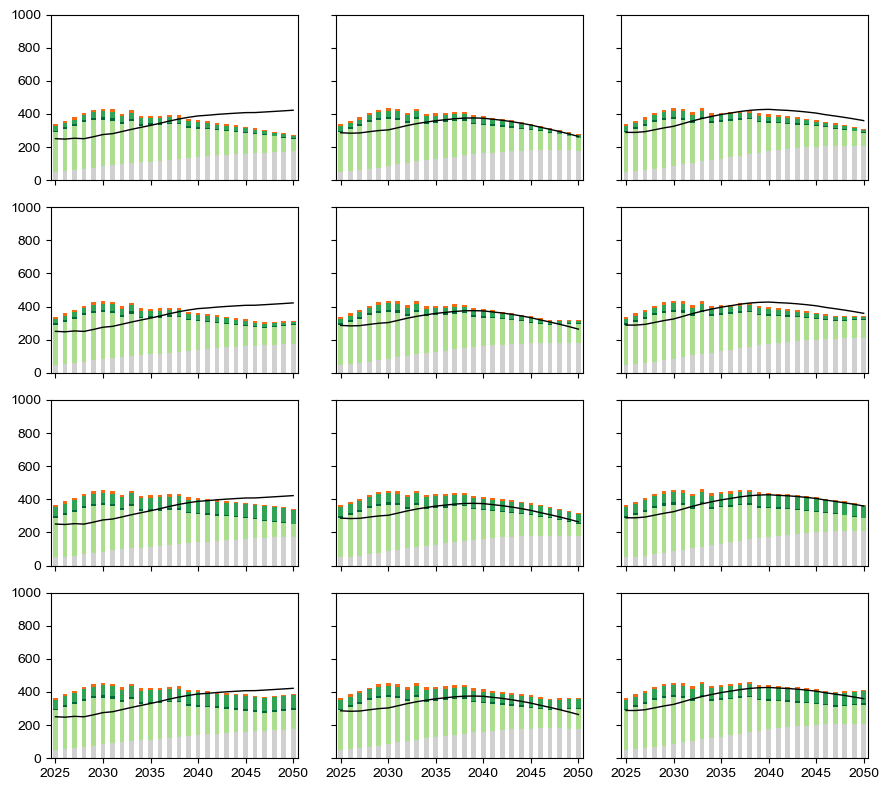

In [49]:
def plot_supply_sources():

    New_Battery_Scenarios = ['NMA', 'LFP/LMFP', 'Na-ion']
    fig, axes = plt.subplots(len(Mining_Scenarios), len(New_Battery_Scenarios), figsize=(9,8), sharex=True, sharey=True) #+['MAX']
    
    for i, m_sce in enumerate(Mining_Scenarios):
        for j, b_sce in enumerate(New_Battery_Scenarios):
        
            lt='Longer'
            seg_sce='Baseline'
            b_size='Larger'
            iea_sce='STEPS'

            df_all_sector_inflow = extract_all_sectors(flow='Inflow', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            df_all_sector_outflow = extract_all_sectors(flow='Outflow', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            #df_all_sector_stock = extract_all_sectors(flow='Stock', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            df_s_demand = cal_all_metal_demand(df_all_sector_inflow, df_all_sector_outflow, df_Co_Surplus, secondary_sce='High', process_sce='Efficient')            
            df_pri_s_p = cal_cobalt_primary_supply(df_Primary_Baseline, df_s_demand)
            df_pri_s_p = max_source(df_pri_s_p)
            df_pri_s_p = re_compile_source(df_pri_s_p)
            
            if m_sce == 'All Carrier-driven':
                m_sce = 'MAX'
            plot_a_supply_source(axes[i,j], m_sce, df_s_demand, df_pri_s_p)
            
            axes[i,j].set_xlabel('')
            axes[i,j].set_ylim(0,1000)
            """if i == 0:
                axes[i,j].set_title(b_sce)
            if j == 0:
                axes[i, j].annotate(m_sce, xy=(-0.23, 0.5), xycoords='axes fraction', 
                                    ha='right', va='center', fontsize=axes[i, 0].title.get_fontsize(), rotation=90)"""

    
    #为最后一个子图添加 legend
    """handles, labels = axes[-1,-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.02), frameon=False)"""
    
    #axes[0].set_ylabel('Global Co primary supply-demand balance (kt)')
    plt.tight_layout()
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Strategy_Contribution/All_Battery_STEPS_Mining_Cobalt_Sources.png', bbox_inches='tight', pad_inches=.1, dpi=500)
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Strategy_Contribution/All_Battery_STEPS_Mining_Cobalt_Sources.svg', bbox_inches='tight', format='svg')
    plt.show()
    

## unit: Mt
plot_supply_sources()

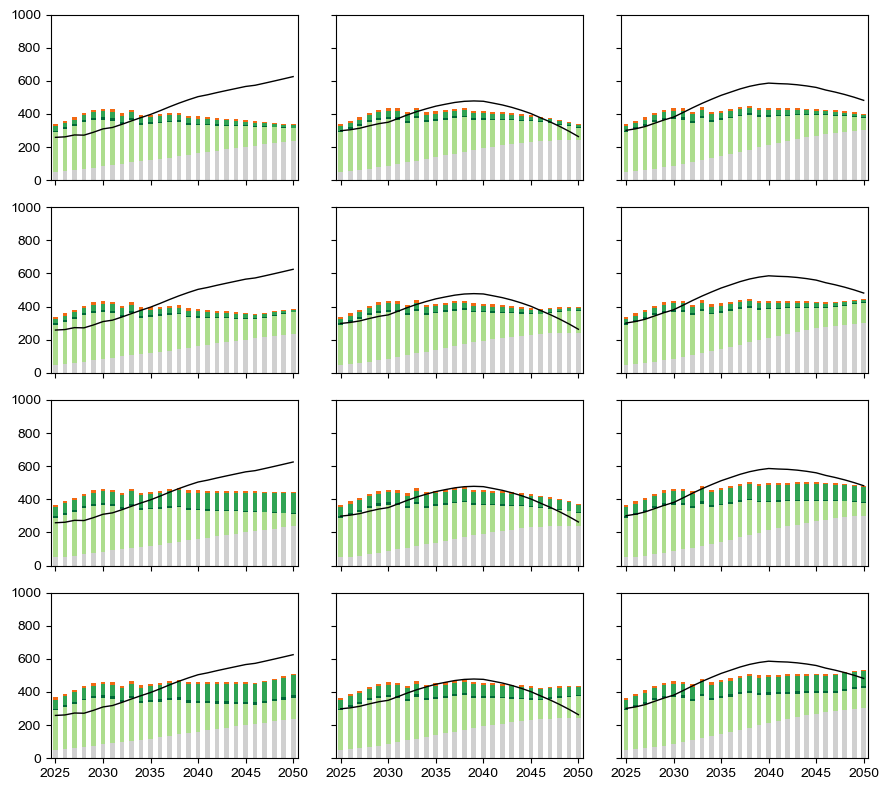

In [50]:
def plot_supply_sources():

    New_Battery_Scenarios = ['NMA', 'LFP/LMFP', 'Na-ion']
    fig, axes = plt.subplots(len(Mining_Scenarios), len(New_Battery_Scenarios), figsize=(9,8), sharex=True, sharey=True) #+['MAX']
    
    for i, m_sce in enumerate(Mining_Scenarios):
        for j, b_sce in enumerate(New_Battery_Scenarios):
        
            lt='Longer'
            seg_sce='Baseline'
            b_size='Larger'
            iea_sce='APS'

            df_all_sector_inflow = extract_all_sectors(flow='Inflow', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            df_all_sector_outflow = extract_all_sectors(flow='Outflow', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            #df_all_sector_stock = extract_all_sectors(flow='Stock', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            df_s_demand = cal_all_metal_demand(df_all_sector_inflow, df_all_sector_outflow, df_Co_Surplus, secondary_sce='High', process_sce='Efficient')            
            df_pri_s_p = cal_cobalt_primary_supply(df_Primary_Baseline, df_s_demand)
            df_pri_s_p = max_source(df_pri_s_p)
            df_pri_s_p = re_compile_source(df_pri_s_p)
            
            if m_sce == 'All Carrier-driven':
                m_sce = 'MAX'
            plot_a_supply_source(axes[i,j], m_sce, df_s_demand, df_pri_s_p)
            
            axes[i,j].set_xlabel('')
            axes[i,j].set_ylim(0,1000)
            """if i == 0:
                axes[i,j].set_title(b_sce)
            if j == 0:
                axes[i, j].annotate(m_sce, xy=(-0.23, 0.5), xycoords='axes fraction', 
                                    ha='right', va='center', fontsize=axes[i, 0].title.get_fontsize(), rotation=90)"""

    
    #为最后一个子图添加 legend
    """handles, labels = axes[-1,-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.02), frameon=False)"""
    
    #axes[0].set_ylabel('Global Co primary supply-demand balance (kt)')
    plt.tight_layout()
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Strategy_Contribution/All_Battery_APS_Mining_Cobalt_Sources.png', bbox_inches='tight', pad_inches=.1, dpi=500)
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Strategy_Contribution/All_Battery_APS_Mining_Cobalt_Sources.svg', bbox_inches='tight', format='svg')
    plt.show()
    

## unit: Mt
plot_supply_sources()

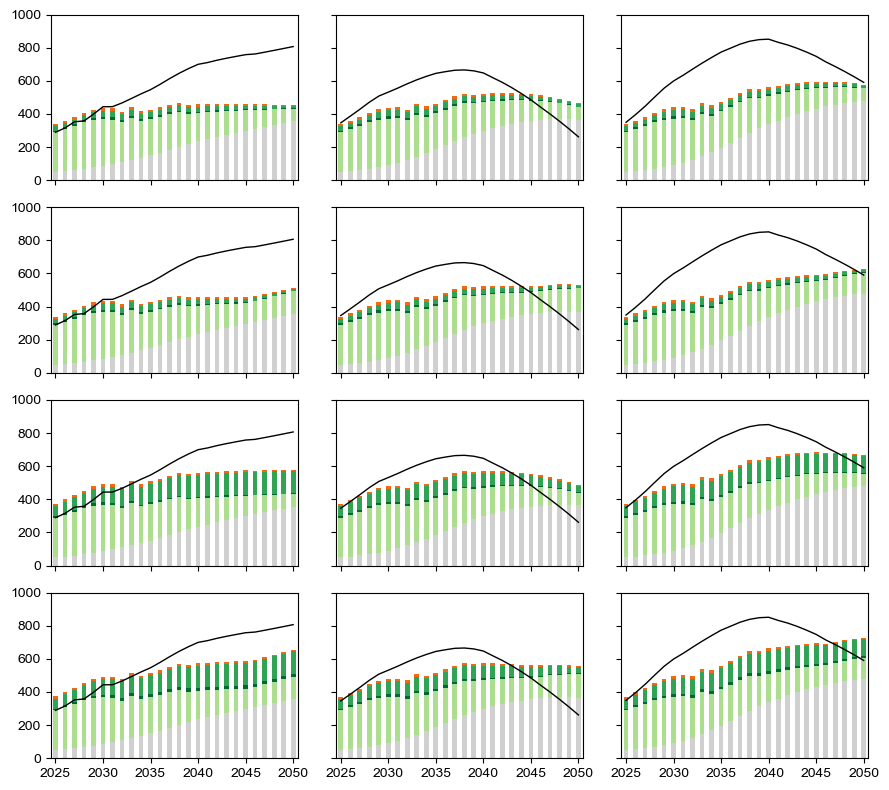

In [51]:
def plot_supply_sources():

    New_Battery_Scenarios = ['NMA', 'LFP/LMFP', 'Na-ion']
    fig, axes = plt.subplots(len(Mining_Scenarios), len(New_Battery_Scenarios), figsize=(9,8), sharex=True, sharey=True) #+['MAX']
    
    for i, m_sce in enumerate(Mining_Scenarios):
        for j, b_sce in enumerate(New_Battery_Scenarios):
        
            lt='Longer'
            seg_sce='Baseline'
            b_size='Larger'
            iea_sce='NZES'

            df_all_sector_inflow = extract_all_sectors(flow='Inflow', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            df_all_sector_outflow = extract_all_sectors(flow='Outflow', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            #df_all_sector_stock = extract_all_sectors(flow='Stock', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            df_s_demand = cal_all_metal_demand(df_all_sector_inflow, df_all_sector_outflow, df_Co_Surplus, secondary_sce='High', process_sce='Efficient')            
            df_pri_s_p = cal_cobalt_primary_supply(df_Primary_Baseline, df_s_demand)
            df_pri_s_p = max_source(df_pri_s_p)
            df_pri_s_p = re_compile_source(df_pri_s_p)
            
            if m_sce == 'All Carrier-driven':
                m_sce = 'MAX'
            plot_a_supply_source(axes[i,j], m_sce, df_s_demand, df_pri_s_p)
            
            axes[i,j].set_xlabel('')
            axes[i,j].set_ylim(0,1000)
            """if i == 0:
                axes[i,j].set_title(b_sce)
            #axes[i,j].set_xlim(2025,2050)
            if j == 0:
                axes[i, j].annotate(m_sce, xy=(-0.23, 0.5), xycoords='axes fraction', 
                                    ha='right', va='center', fontsize=axes[i, 0].title.get_fontsize(), rotation=90)"""
            if m_sce == 'MAX':
                with pd.ExcelWriter(file_path + 'Scenarios/plot_Strategy/Strategy_Contribution/extended_Fig5_'+b_sce[:3]+'_.xlsx') as writer:
                    df_all_sector_inflow_2.to_excel(excel_writer = writer, sheet_name='Annual_inflow')
                    df_s_demand.to_excel(excel_writer = writer, sheet_name='Supply_Demand')
                    df_pri_s_p.to_excel(excel_writer = writer, sheet_name='Primary_Supply_Potential')
    
    """#为最后一个子图添加 legend
    handles, labels = axes[-1,-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.02), frameon=False)"""
    
    #axes[0].set_ylabel('Global Co primary supply-demand balance (kt)')
    plt.tight_layout()
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Strategy_Contribution/All_Battery_NZES_Mining_Cobalt_Sources.png', bbox_inches='tight', pad_inches=.1, dpi=500)
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Strategy_Contribution/All_Battery_NZES_Mining_Cobalt_Sources.svg', bbox_inches='tight', format='svg')
    plt.show()
    

## unit: Mt
plot_supply_sources()

In [ ]:
end_time = time.time()
execution_time = end_time - start_time
hours = execution_time // 3600 
minutes = (execution_time % 3600) // 60 
seconds = execution_time % 60 

print(f"代码运行时间: {int(hours)}小时 {int(minutes)}分钟 {int(seconds)}秒")

代码运行时间: 0小时 1分钟 18秒
